In [2]:
## 📌 Project: E-commerce sales analysis 
# Autor: Daria Ermak
# Objective: Research user behavior and sales, identify business insights

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/Users/dashkaermak/Desktop/Datasets/ecommerce_data.csv")

In [6]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.8+ GB


,product_id,category_id,price,user_id
count,4.244876e+07,4.244876e+07,4.244876e+07,4.244876e+07
mean,1.054993e+07,2.057404e+18,2.903237e+02,5.335371e+08
std,1.188191e+07,1.843926e+16,3.582692e+02,1.852374e+07
min,1.000978e+06,2.053014e+18,0.000000e+00,3.386938e+07
25%,1.005157e+06,2.053014e+18,6.598000e+01,5.159043e+08
50%,5.000470e+06,2.053014e+18,1.629300e+02,5.296965e+08
75%,1.600030e+07,2.053014e+18,3.585700e+02,5.515788e+08
max,6.050001e+07,2.175420e+18,2.574070e+03,5.662809e+08


In [9]:
pd.set_option('display.float_format', '{:.0f}'.format)

In [10]:
df.describe()

,product_id,category_id,price,user_id
count,42448764,42448764,42448764,42448764
mean,10549932,2057404237940798720,290,533537148
std,11881907,18439264661404152,358,18523738
min,1000978,2053013552226107648,0,33869381
25%,1005157,2053013555464110592,66,515904318
50%,5000470,2053013555631882752,163,529696452
75%,16000305,2053013563424899840,359,551578838
max,60500010,2175419595093967616,2574,566280860


In [11]:
df.duplicated().sum()
df.isna().sum()
df['event_time'] = pd.to_datetime(df['event_time'])

Text(0.5, 1.0, 'Events: View, Cart, Purchase')

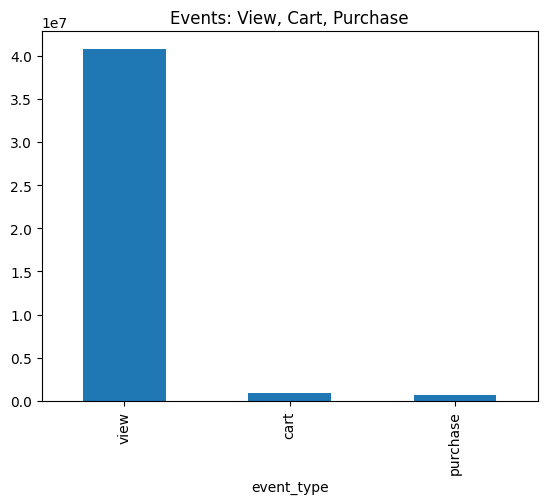

In [12]:
# Number of events by type

df['event_type'].value_counts().plot(kind='bar')
plt.title('Events: View, Cart, Purchase')

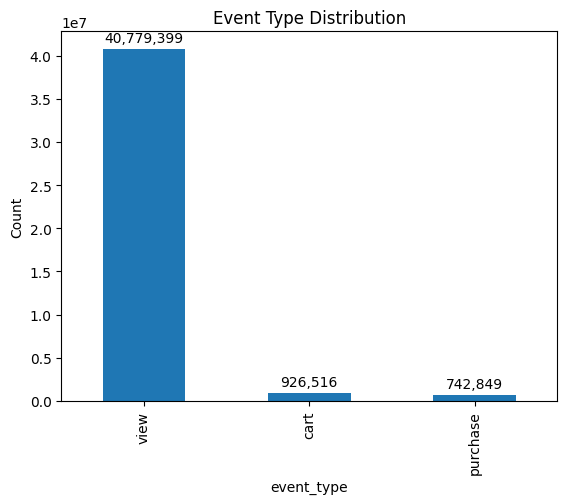

In [14]:
value_counts = df['event_type'].value_counts()
ax = value_counts.plot(kind='bar')
plt.title('Event Type Distribution')
plt.ylabel('Count')


for i, val in enumerate(value_counts):
    ax.text(i, val + 0.01 * max(value_counts), f'{val:,}', ha='center', va='bottom')

plt.show()

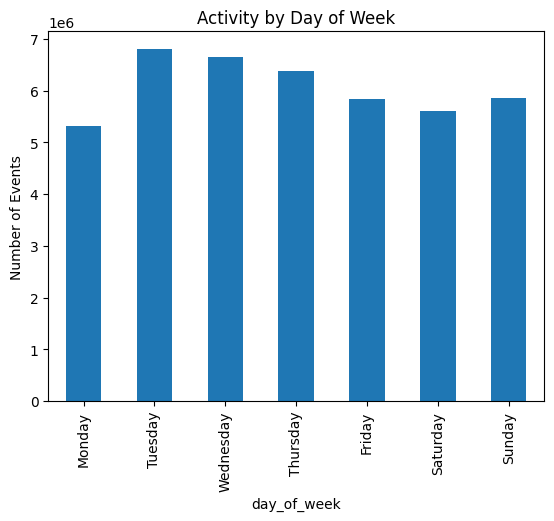

In [19]:
# Activity by day of week

df['event_date'] = df['event_time'].dt.date
df['day_of_week'] = df['event_time'].dt.day_name()


df.groupby('day_of_week').size().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).plot(kind='bar', title='Activity by Day of Week')
plt.ylabel('Number of Events')
plt.show()

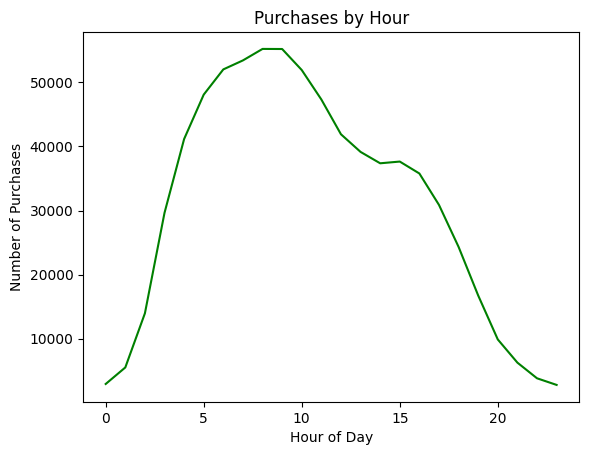

In [18]:
# Purchases by hour

df[df['event_type'] == 'purchase'].groupby(df['event_time'].dt.hour).size().plot(
    title='Purchases by Hour', color='green')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Purchases')
plt.show()

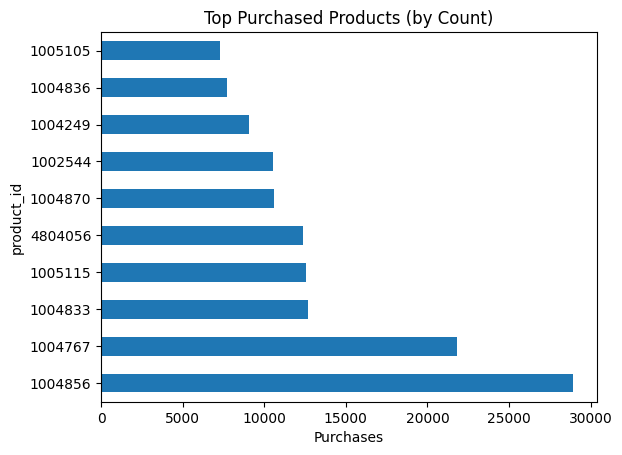

In [20]:
# Top purchases products 

df[df['event_type'] == 'purchase']['product_id'].value_counts().head(10).plot(
    kind='barh', title='Top Purchased Products (by Count)')
plt.xlabel('Purchases')
plt.show()

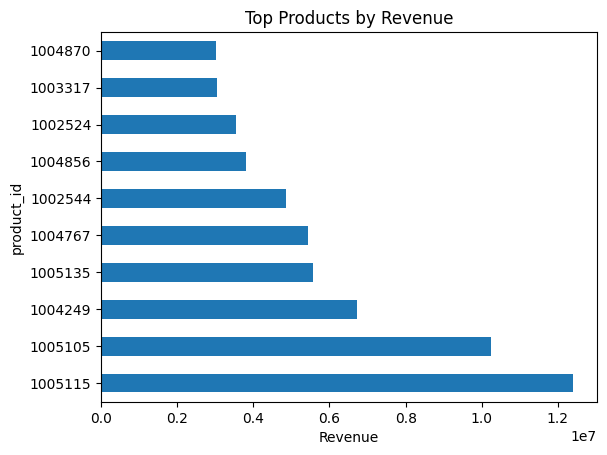

In [21]:
# Top products by Revenue

df[df['event_type'] == 'purchase'].groupby('product_id')['price'].sum().sort_values(ascending=False).head(10).plot(
    kind='barh', title='Top Products by Revenue')
plt.xlabel('Revenue')
plt.show()

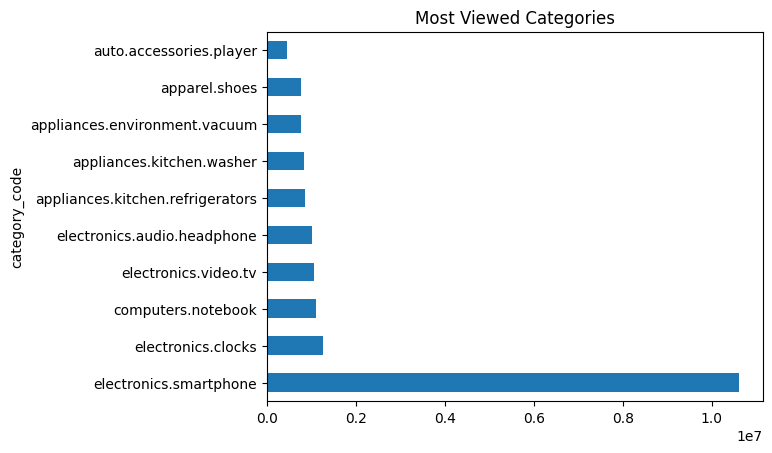

In [22]:
# Most viewed categories

df[df['event_type'] == 'view'].groupby('category_code').size().sort_values(ascending=False).head(10).plot(
    kind='barh', title='Most Viewed Categories')
plt.show()

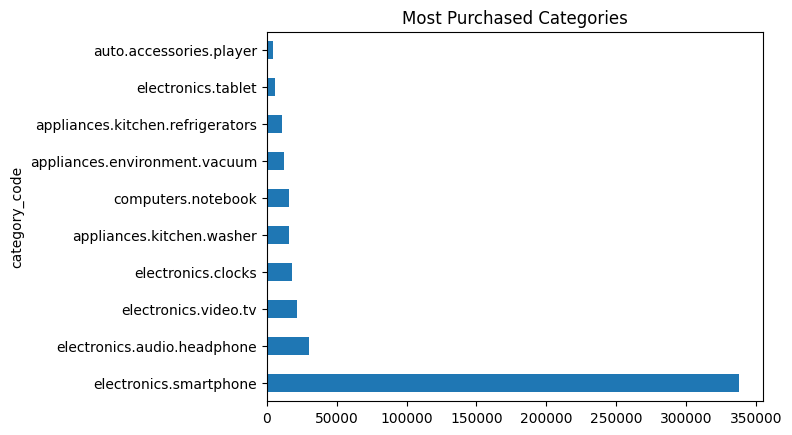

In [23]:
# Most purchased categories

df[df['event_type'] == 'purchase'].groupby('category_code').size().sort_values(ascending=False).head(10).plot(
    kind='barh', title='Most Purchased Categories')
plt.show()

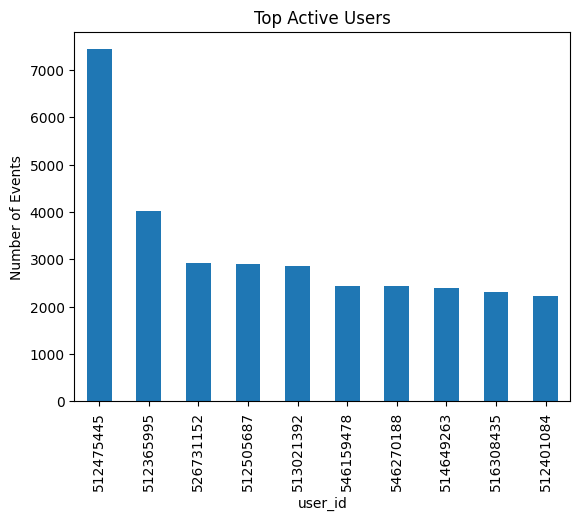

In [25]:
# Top active users

df['user_id'].value_counts().head(10).plot(kind='bar', title='Top Active Users')
plt.ylabel('Number of Events')
plt.show()

In [26]:
# Conversion rate

conversion = df.groupby('event_type')['user_id'].nunique()
viewers = conversion.get('view', 1)
cart_adders = conversion.get('cart', 0)
buyers = conversion.get('purchase', 0)

view_to_cart = (cart_adders / viewers) * 100
cart_to_buy = (buyers / cart_adders) * 100 if cart_adders > 0 else 0

print(f"View to Cart Conversion: {view_to_cart:.2f}%")
print(f"Cart to Purchase Conversion: {cart_to_buy:.2f}%")

View to Cart Conversion: 11.15%
Cart to Purchase Conversion: 102.97%


## 📌 Final Evaluation

## ✅ Project Summary: E-commerce User Behavior Analysis

### 🔍 Goal:
To analyze user behavior and purchasing patterns in an online store, in order to discover insights, identify inefficiencies, and suggest improvements based on the data.

---

### 🔢 Detailed Insights & Recommendations

### 1. Event Type Distribution
There is a dramatic gap between the number of views and actual purchases: over **40 million product views** versus only **~742,000 purchases**. This reflects a low conversion rate.

**Possible Causes:**
- Lack of appealing product presentation
- High pricing
- Unclear value proposition

**Recommendation:**  
Target high-traffic but low-conversion products with enhanced product pages, price testing, and dedicated advertising campaigns.

---

### 2. Activity by Day of Week
User engagement is distributed fairly evenly across all days, but the most active days are **Tuesday, Wednesday, and Thursday**, with **Monday** being the slowest.

**Recommendation:**  
Schedule major promotions and product launches mid-week to capitalize on peak engagement.

---

### 3. Purchase Activity by Hour
The highest volume of purchases occurs between **2 AM and 9 AM**, which is surprising. This pattern might reflect the time zones of users (e.g., international traffic), where those hours map to daytime.

**Recommendation:**  
Use geolocation data to align email, push, or ad campaigns with user activity windows in their local time.

---

### 4. Top Purchased Products (by Volume)
Two products stand out significantly:
- `product_id 1004856`: ~28,000 purchases  
- `product_id 1004767`: ~22,000 purchases  
All other top products have <14,000 purchases.

**Recommendation:**  
Focus additional marketing or bundling efforts around these top performers. Consider loyalty bonuses or exclusive bundles.

---

### 5. Top Revenue Products
Products with the highest revenue are **not** necessarily the top-selling:
- `product_id 1005115` and `1005105` generate more revenue while being only 4th and 10th in volume.

**Recommendation:**  
Feature these premium items more prominently — they offer a higher return per sale.

---

### 6. Category Analysis
The leading category by both views and purchases is **electronics.smartphone**, making it a key focus area.

**Recommendation:**  
Double down on smartphone promotions, category-specific deals, and explore cross-selling opportunities.

---

### 7. High-Value Customers
Some users show extremely high purchase activity. These could be loyal customers or B2B clients.

**Recommendation:**  
Introduce tiered loyalty programs or volume-based discounts. Use available demographic data to define customer segments and focus acquisition efforts.

---

## 📊 Visuals Included:
- Bar charts: event types, days of week, hourly purchases
- Top 10 products by quantity and revenue
- Category comparisons: views vs purchases
- Top users by engagement

---

## 🚀 Next Steps:
- Cluster users by behavior to discover segments
- Use machine learning to predict conversion
- Include session data (time on site, bounce rate)
- Run cohort analysis to track retention and repeat behavior

---

### 👤 Author:
*Daria Ermak*  
*GitHub:* https://github.com/DariaErmak08?tab=repositories